In [ ]:
dataset- https://www.kaggle.com/datasets/ciochdawid/dailydelhiclimatetrain-csv

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.set_index('date', inplace=True)
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
data = df[['meantemp']].values

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [11]:
X, y = [], []
seq_len = 30
for i in range(seq_len, len(data)):
  X.append(data[i-seq_len:i])   # past 30 days
  y.append(data[i])  # next day

X = np.array(X)
y = np.array(y)

In [14]:
from keras.models import Sequential
model = Sequential()

In [15]:
from keras.layers import LSTM, Dense

In [16]:
model.add(LSTM(50, input_shape=(seq_len, 1)))    # input shape = (timesteps, features)
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(optimizer='adam', loss='mse')

In [24]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss', patience=2, restore_best_weights=True)
model.fit(X, y, epochs = 10, batch_size=32, callbacks=[early_stopping])

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 6.9832e-04 - loss: 0.0028
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 6.9832e-04 - loss: 0.0027
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 6.9832e-04 - loss: 0.0027
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 6.9832e-04 - loss: 0.0026
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 6.9832e-04 - loss: 0.0026
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 6.9832e-04 - loss: 0.0027
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 6.9832e-04 - loss: 0.0025
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 6.9832e-04 - loss: 0.0025
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 6.9832e-04 - loss: 0.0025
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 6.9832e-04 - loss: 0.0025


In [25]:
pred = model.predict(X)
pred = scaler.inverse_transform(pred)
y = scaler.inverse_transform(y)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


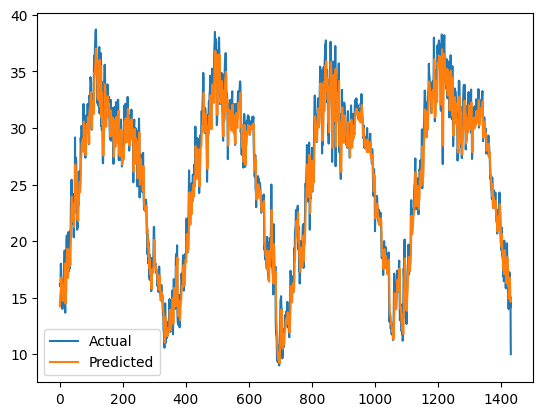

In [26]:
plt.plot(y, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [28]:
print(X.shape)
print(y.shape)

(1432, 30, 1)
(1432, 1)


In [30]:
# predicting next value
last_30 = data[-30:]
last_30 = np.expand_dims(last_30, axis=0) # Add a batch dimension
next_temp = model.predict(last_30)
next_temp = scaler.inverse_transform(next_temp)
print("Next day temp: ", next_temp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Next day temp:  [[11.934038]]
